# Active Discovery of Latent Dynamic Mediators

To start we assume that in our training set we have recordings of $N$ independent patients. Each patient $n$ is associated with two time series signals, $x_n(t)$ and $y_n(t)$, and a treatment group label $c_n \in \mathcal{C}$ provided by an expert. The treatment group $c_n$ identifies which causal pathway is responsible for generating $y_n(t)$. The pathway $c_n$ is associated with a particular causal model $M_{c_n}$ that generated $y_n(t)$  conditional on a latent mediation process $z_n(t)$.

There are two SSMs indexed by $j\in \{0,1\}$, where $j$ represents the group:
$$z_t := \alpha_j x_t + \lambda_j z_{t-1} + w_t,
    \qquad w \sim \mathcal{N}(0,\sigma_w)$$
$$y_t := \beta_j z_{t} + \gamma_j x_t + e_t,
    \qquad e_t \sim \mathcal{N}(0,\sigma_e)
$$

In [1]:
from utils.data_generation import generate_synthetic_samples, PatientSimulator
from utils.plots import plot_scatter_by_group, plot_trajectories, plot_mean_std, plot_accuracy_active_learning
from utils.em_algorithm import em_ssm
from utils.infer_patient import infer_patient
from utils.active_learning import run_patient_with_active_learning, POLICY_LABELS
from utils.baseline import logistic_regression_prediction
import numpy as np

# Reproducibility: every stochastic step below takes an explicit seed derived
# from SEED, and each gets its own stream. See README > Reproducibility.
SEED = 0
np.random.seed(SEED)  # belt-and-braces default only; nothing here relies on it

## Phase 1: training

### Data Visualization

In [2]:
# generate synthetic training samples
j_train, X_train, Z_train, Y_train = generate_synthetic_samples(n_patients=100, T=50, seed=(SEED, 0))

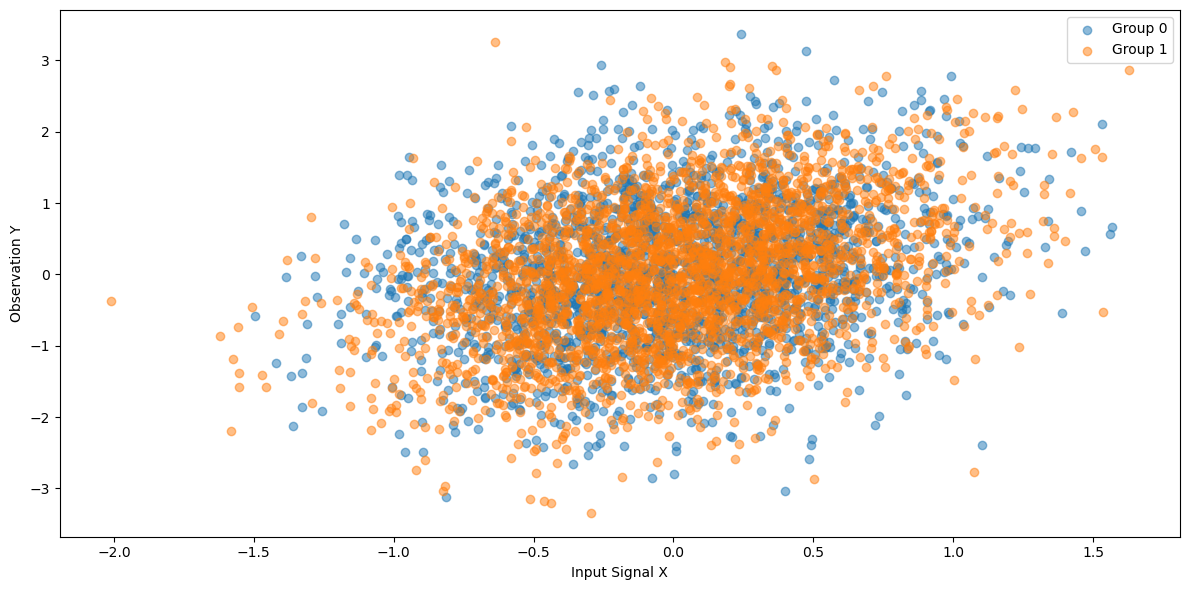

In [3]:
plot_scatter_by_group(X_train, Y_train, groups=j_train)

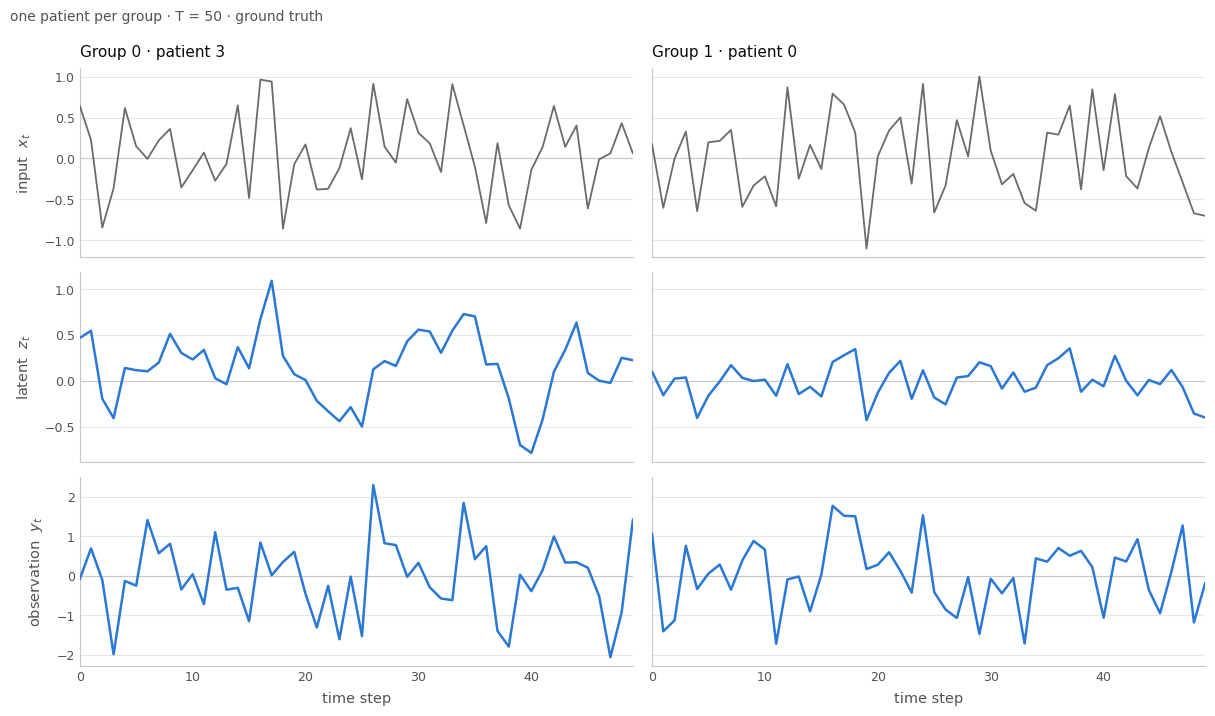

In [4]:
plot_trajectories(X_train, Z_train, Y_train, groups=j_train)

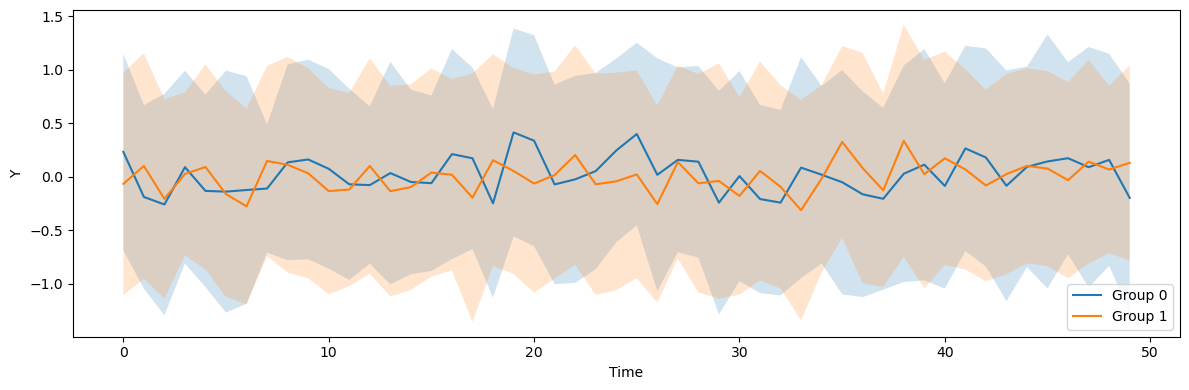

In [5]:
plot_mean_std(Y_train, groups=j_train)

### Estimation using EM algorithm

In [6]:
# separate the data into the two groups
# run em algorithm on each group separately
estimated_params = {}
for group in [0, 1]:
        idx = j_train == group
        X_group = X_train[idx]
        Y_group = Y_train[idx]
 
        est_params, log_liks = em_ssm(
            X_group, Y_group,
            alpha_init=0.5, lam_init=0.5, beta_init=0.5, gamma_init=0.5,
            sigma_w_init=0.2,   # sigma_e_init defaults to np.std(Y)
        )

        estimated_params[group] = est_params
 
        print(f"\nGroup {group} estimated params:")
        for k, v in est_params.items():
            print(f"  {k}: {v:.4f}")
            #print(f"Log-likelihood: {log_liks}.")

Converged at iteration 243

Group 0 estimated params:
  alpha: 0.5067
  lam: 0.7276
  beta: 0.6935
  gamma: 0.1436
  sigma_w: 0.1954
  sigma_e: 0.9000



Group 1 estimated params:
  alpha: 0.4184
  lam: 0.2947
  beta: 0.9412
  gamma: 0.3366
  sigma_w: 0.2240
  sigma_e: 0.8792


/tmp/ipykernel_60691/622741755.py:9: RuntimeWarning: em_ssm did not converge in 1000 iterations (last log-likelihood change 2.023e-04, relative tol 1e-08). Returning the best iterate (iteration 1000, log-likelihood -3697.7143).
  est_params, log_liks = em_ssm(


### Visualize the Predicted Trajectories of $z_t$ and $y_t$

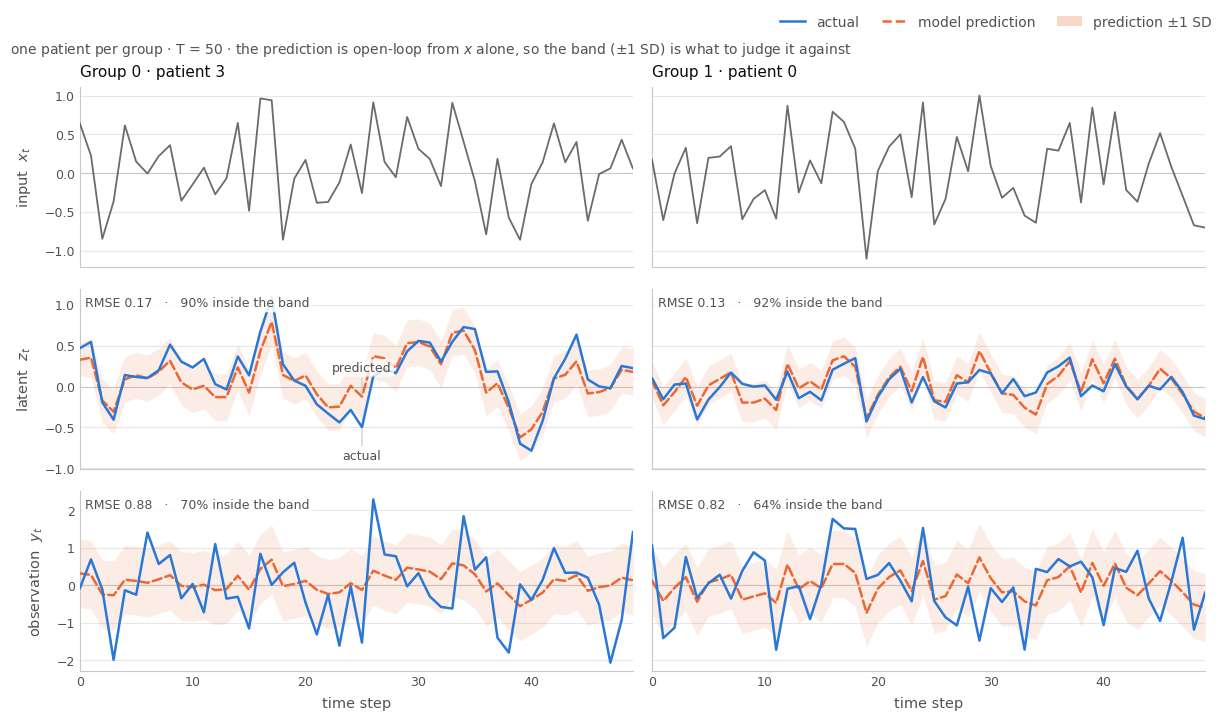

In [7]:
plot_trajectories(X_train, Z_train, Y_train, groups=j_train, estimated_params=estimated_params)

## Phase 2: classification via filtering

In [8]:
# generate synthetic testing samples
j_test, X_test, Z_test, Y_test = generate_synthetic_samples(n_patients=100, T=50, seed=(SEED, 1))

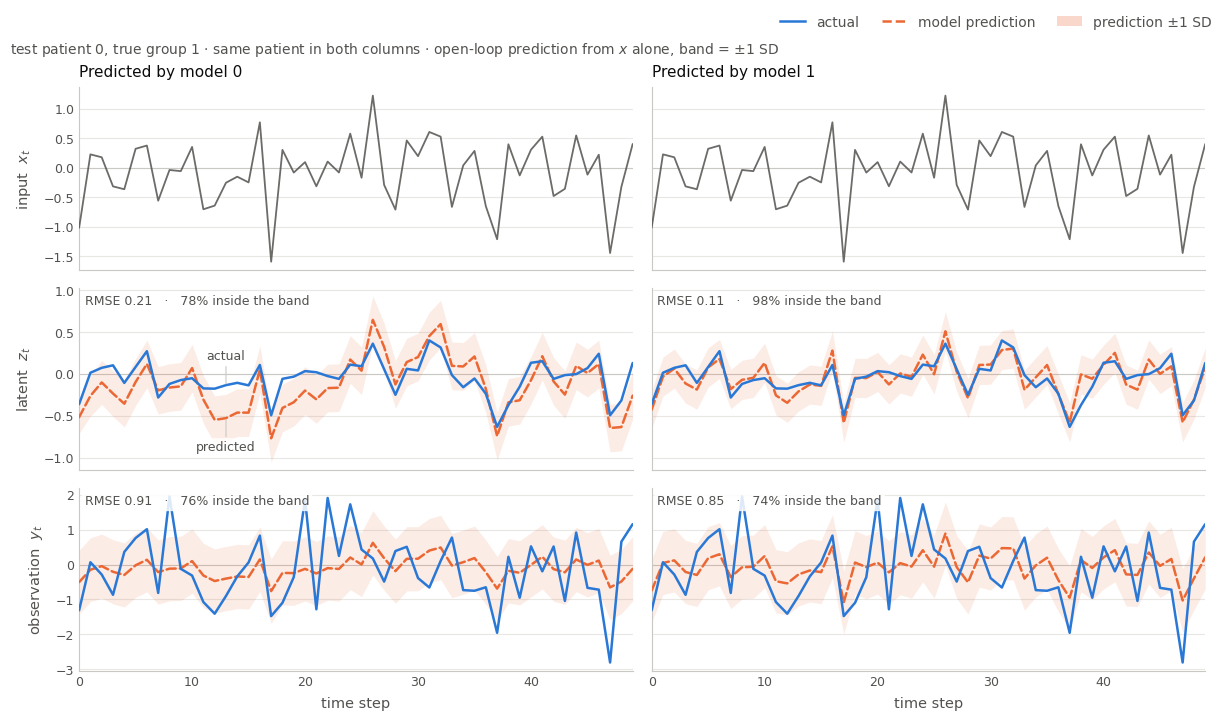

Our approach:
Accuracy: 0.7800  (78/100 correct)

Baseline approach (logistic regression):
Accuracy (using full time series): 0.4200  (42/100 correct)
Accuracy (using moments): 0.4800  (48/100 correct)


In [9]:
predictions = []
for n in range(len(j_test)):
    if n == 0:
        # One test patient, predicted by each fitted model in turn: the same
        # trajectory is duplicated so that each column of the figure shows one
        # model's attempt at it. The column whose prediction tracks the actual
        # observations more closely is the one the likelihood ratio picks.
        plot_trajectories(
            np.tile(X_test[n], (2, 1)),
            np.tile(Z_test[n], (2, 1)),
            np.tile(Y_test[n], (2, 1)),
            groups=np.array([0, 1]),
            group_labels={0: "Predicted by model 0", 1: "Predicted by model 1"},
            estimated_params=estimated_params,
            # No title; the identifying detail it used to carry moves into the
            # subtitle, which is the one line the figure cannot do without --
            # without it the two columns read as two different patients.
            subtitle=(f"test patient {n}, true group {j_test[n]} · same patient in both "
                      "columns · open-loop prediction from $x$ alone, band = ±1 SD"),
        )
    prob_1, c_n, _, _ = infer_patient(X_test[n], Y_test[n], estimated_params[0], estimated_params[1])
    predictions.append(c_n)

predictions = np.array(predictions)
accuracy = np.mean(predictions == j_test)
print("Our approach:")
print(f"Accuracy: {accuracy:.4f}  ({int(accuracy * len(j_test))}/{len(j_test)} correct)")

print("\nBaseline approach (logistic regression):")
baseline_predictions = logistic_regression_prediction(X_train, Y_train, j_train, X_test, Y_test, variant='full time series')
baseline_accuracy = np.mean(baseline_predictions == j_test)
print(f"Accuracy (using full time series): {baseline_accuracy:.4f}  ({int(baseline_accuracy * len(j_test))}/{len(j_test)} correct)")

baseline_predictions_moments = logistic_regression_prediction(X_train, Y_train, j_train, X_test, Y_test, variant='distribution moments')
baseline_accuracy_moments = np.mean(baseline_predictions_moments == j_test)
print(f"Accuracy (using moments): {baseline_accuracy_moments:.4f}  ({int(baseline_accuracy_moments * len(j_test))}/{len(j_test)} correct)")

### Active learning

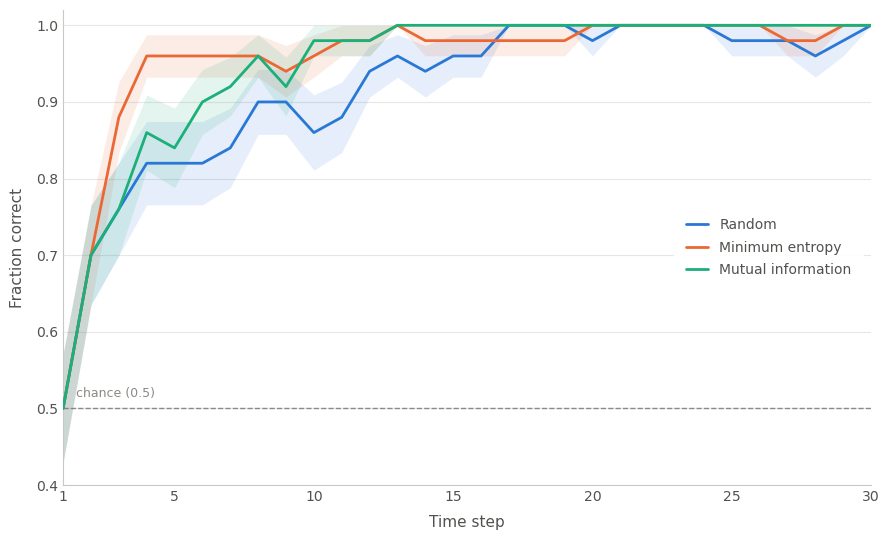

In [10]:
n_patients = 50
T = 30
policies = ["random", "uncertainty sampling", "mutual information"]
# to account for time step 0
correct = {pol: np.zeros((n_patients, T), dtype=bool) for pol in policies}
candidates = np.linspace(-4, 4, 33)

for i in range(n_patients):
    true_group = i % 2
    #patient = PatientSimulator(true_group)

    for policy in policies:
        # seed=i: same noise realisation for every policy (paired comparison),
        # and a per-patient probe sequence / Monte Carlo stream.
        patient = PatientSimulator(true_group, seed=i)
        _, correct_t = run_patient_with_active_learning(patient, estimated_params, candidates, policy=policy, T=T, seed=i)
        correct[policy][i] = correct_t

accuracy = {pol: correct[pol].mean(axis=0) for pol in policies} 
sem = {pol: correct[pol].std(axis=0)/np.sqrt(n_patients) for pol in policies} # standard error of the mean

# Figures carry the display names ("Minimum entropy"); the policy identifiers
# stay lowercase, because they also index the Monte Carlo streams.
plot_accuracy_active_learning(
    {POLICY_LABELS[pol]: accuracy[pol] for pol in policies},
    {POLICY_LABELS[pol]: sem[pol] for pol in policies},
)